In [2]:
import pandas as pd

In [40]:
BASE_DATA = "data/"
START_DATE = '01/01/2019'
# 1. Đọc dữ liệu
orders = pd.read_csv(BASE_DATA+'orders.csv', parse_dates=['order_date'])
payments = pd.read_csv(BASE_DATA+'payments.csv')
returns = pd.read_csv(BASE_DATA+'returns.csv')
orders = orders[orders['order_date'] >= START_DATE]
valid_order_ids = orders['order_id'].unique()
payments = payments[payments['order_id'].isin(valid_order_ids)]
returns = returns[returns['order_id'].isin(valid_order_ids)]

In [42]:

# Xác định ngày "hiện tại" để tính Recency 
analysis_date = pd.to_datetime("01/01/2023")
# 2. Xử lý Monetary (Net Revenue)
# Tính tổng tiền trả theo đơn hàng
payment_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Tính tổng tiền hoàn lại theo đơn hàng
return_agg = returns.groupby('order_id')['refund_amount'].sum().reset_index()

# Join để tính giá trị thực tế của mỗi đơn hàng
order_value = pd.merge(payment_agg, return_agg, on='order_id', how='left').fillna(0)
order_value['net_amount'] = order_value['payment_value'] - order_value['refund_amount']

In [98]:
# 3. Tổng hợp dữ liệu vào bảng Orders
# Chỉ tính các đơn hàng thành công (delivered/shipped) để tránh nhiễu Frequency
successful_orders = orders[orders['order_status'].isin(['delivered', 'shipped'])]
df_final = pd.merge(successful_orders, order_value[['order_id', 'net_amount']], on='order_id', how='left')

# 4. Tính toán R, F, M theo từng Customer
rfm = df_final.groupby('customer_id').agg({
    'order_date': lambda x: (analysis_date - x.max()).days, # Recency
    'order_id': 'count',                                   # Frequency
    'net_amount': 'sum'                                    # Monetary
})

# Đổi tên cột cho rõ ràng
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())

             Recency  Frequency  Monetary
customer_id                              
1               1042          1   4233.33
2                179          1  59996.55
4                917          1  10939.06
5               1376          1   8931.28
6                560          1  14971.60


In [99]:
# 1. Recency: Càng nhỏ càng tốt 
# Để "Dưới 50% (về mặt xếp hạng) là Low", ta rank theo ascending=False
# Những người mua xa nhất sẽ có Rank thấp nhất -> Nhận nhãn Low
rfm['R_Rank'] = rfm['Recency'].rank(method='min', ascending=False)
rfm['F_Rank'] = rfm['Frequency'].rank(method='min', ascending=True)
rfm['M_Rank'] = rfm['Monetary'].rank(method='min', ascending=True)

rfm['R_Score'] = pd.qcut(rfm['R_Rank'], 2, labels=["Low", "High"], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['F_Rank'], 2, labels=["Low", "High"], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['M_Rank'], 2, labels=["Low", "High"], duplicates='drop')


In [103]:
# Tạo cột Segment dựa trên logic High/Low
def segment_high_low(df):
    r, f, m = df['R_Score'], df['F_Score'], df['M_Score']
    
    if r == 'High' and f == 'High' and m == 'High': return 'Key Valuable Customer'
    if r == 'Low' and f == 'High' and m == 'High': return 'Key Loyal Customer'
    if r == 'High' and f == 'Low' and m == 'High': return 'Key Potential Customer'
    if r == 'Low' and f == 'Low' and m == 'High': return 'Key At Risk Customer'
    if r == 'High' and f == 'High' and m == 'Low': return 'General Valuable Customer'
    if r == 'Low' and f == 'High' and m == 'Low': return 'General Loyal Customer'
    if r == 'High' and f == 'Low' and m == 'Low': return 'General Potential Customer'
    return 'Lost'



In [104]:
rfm['Segment'] = rfm.apply(segment_high_low, axis=1)

In [ ]:
print(rfm[rfm['Segment']=='Lost']["Frequency"].min())
print(rfm[rfm['Segment']=='Lost']["Frequency"].max())

np.int64(2)

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_92462/954373210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Segment', data=segment_counts, palette='viridis')


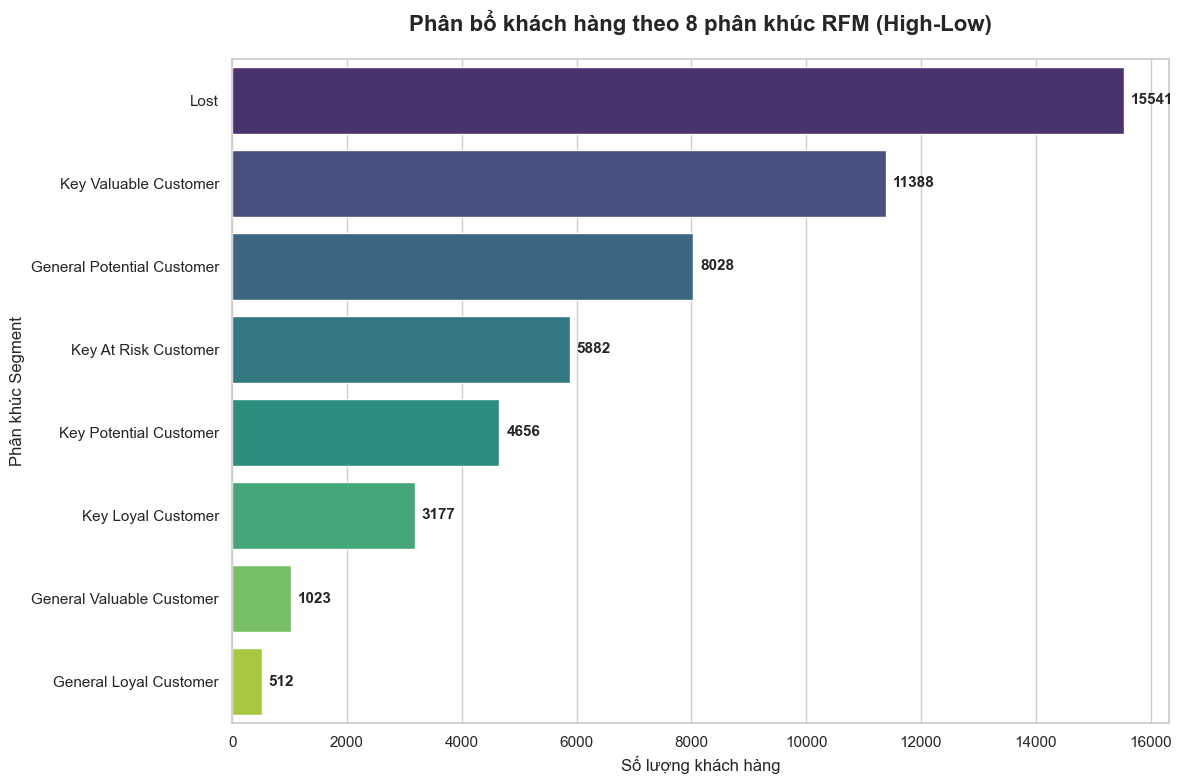

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán số lượng cho mỗi Segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# 2. Sắp xếp theo số lượng giảm dần để biểu đồ trực quan hơn
segment_counts = segment_counts.sort_values(by='Count', ascending=False)

# 3. Cấu hình biểu đồ
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột ngang (barplot)
ax = sns.barplot(x='Count', y='Segment', data=segment_counts, palette='viridis')

# 4. Thêm số liệu cụ thể vào cuối mỗi thanh (Annotation)
for i, p in enumerate(ax.patches):
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# 5. Tinh chỉnh tiêu đề và nhãn trục
plt.title('Phân bổ khách hàng theo 8 phân khúc RFM (High-Low)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng khách hàng', fontsize=12)
plt.ylabel('Phân khúc Segment', fontsize=12)

# Tối ưu hóa không gian hiển thị
plt.tight_layout()

# Lưu hoặc hiển thị
plt.savefig('rfm_segments_barplot.png')
plt.show()